# Fitting and Explaining Expected Goals Models

This notebook loads `isli_shots.csv` (produced by `create_xG_features.ipynb`)
and fits two neural network xG models:

- **Model A** — 9 tracking features only (no Basic xG)
- **Model B** — 10 features including Basic xG

We compare their ROC and calibration curves, then use SHAP values to
explain what each model has learned.

## Setup

In [1]:
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
import os
import random as rn
import tensorflow as tf
import shap
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, roc_auc_score, brier_score_loss
from sklearn.calibration import calibration_curve
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

pd.options.mode.chained_assignment = None
warnings.filterwarnings('ignore')
os.environ['PYTHONHASHSEED'] = '0'
os.environ['CUDA_VISIBLE_DEVICES'] = ''
np.random.seed(1)
rn.seed(1)
tf.random.set_seed(1)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# Load features
model_vars = pd.read_csv('isli_shots.csv')
X_all = model_vars[['x0', 'is_closer', 'angle', 'distance', 'gk_distance',
                     'gk_distance_y', 'triangle', 'close_players', 'header', 'xg_basic']].values
y = model_vars['goal'].values

# Train / validation / calibration split
X_train_all, X_test, y_train, y_test = train_test_split(X_all, y, train_size=0.6, random_state=123, stratify=y)
X_cal_all,   X_val_all, y_cal, y_val = train_test_split(X_test, y_test, train_size=0.5, random_state=123, stratify=y_test)

# Scale using all 10 features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_all)
X_val   = scaler.transform(X_val_all)
X_cal   = scaler.transform(X_cal_all)

# Subsets without xg_basic (first 9 columns)
X_train_A = X_train[:, :9]
X_val_A   = X_val[:, :9]
X_cal_A   = X_cal[:, :9]

# Feature labels
feature_info = {
    'x0':            ('Ball X-position',               'How far along the pitch the shot was taken (meters from own goal)'),
    'is_closer':     ('Ball closer to goal than GK',   '1 if the ball is nearer the goal than the goalkeeper, 0 otherwise'),
    'angle':         ('Shot angle',                    'Angle (degrees) subtended by the goal posts from the ball position'),
    'distance':      ('Shot distance',                 'Straight-line distance (meters) from the ball to the centre of the goal'),
    'gk_distance':   ('Distance to goalkeeper',        'Straight-line distance (meters) from the ball to the goalkeeper'),
    'gk_distance_y': ('Y-axis distance to goalkeeper', 'Lateral distance (meters) between the ball and the goalkeeper'),
    'triangle':      ('Opponents in shooting triangle','Number of opposition players inside the triangle formed by the ball and goalposts'),
    'close_players': ('Opponents within 3 m',          'Number of opposition players within 3 metres of the ball'),
    'header':        ('Header',                        '1 if the shot was a header, 0 otherwise'),
    'xg_basic':      ('Basic xG',                      'Expected goals from a simple logistic model using only angle and distance'),
}
keys_A = ['x0','is_closer','angle','distance','gk_distance','gk_distance_y','triangle','close_players','header']
keys_B = keys_A + ['xg_basic']
labels_A = [feature_info[k][0] for k in keys_A]
labels_B = [feature_info[k][0] for k in keys_B]

# Model architecture
def create_model():
    model = Sequential([
        Dense(10, activation='relu'),
        Dense(10, activation='relu'),
        Dense(1,  activation='sigmoid'),
    ])
    model.compile(optimizer=Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999),
                  loss='mean_squared_error', metrics=['accuracy'])
    return model

## Fitting both models

We train two identical networks — one on 9 tracking features (Model A)
and one with Basic xG added as a 10th feature (Model B).

In [2]:
cb = lambda: EarlyStopping(min_delta=1e-5, patience=50, mode='min',
                            monitor='val_loss', restore_best_weights=True)

print('Training Model A (without Basic xG)...')
model_A = create_model()
model_A.fit(X_train_A, y_train, validation_data=(X_val_A, y_val),
            epochs=1000, verbose=0, batch_size=16, callbacks=[cb()])

print('Training Model B (with Basic xG)...')
model_B = create_model()
model_B.fit(X_train,   y_train, validation_data=(X_val,   y_val),
            epochs=1000, verbose=0, batch_size=16, callbacks=[cb()])

print('Both models trained.')

Training Model A (without Basic xG)...
Training Model B (with Basic xG)...
Both models trained.


## Assessing both models

We plot both ROC curves on the same axes, and both calibration curves
side by side, so we can directly compare the two models.

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


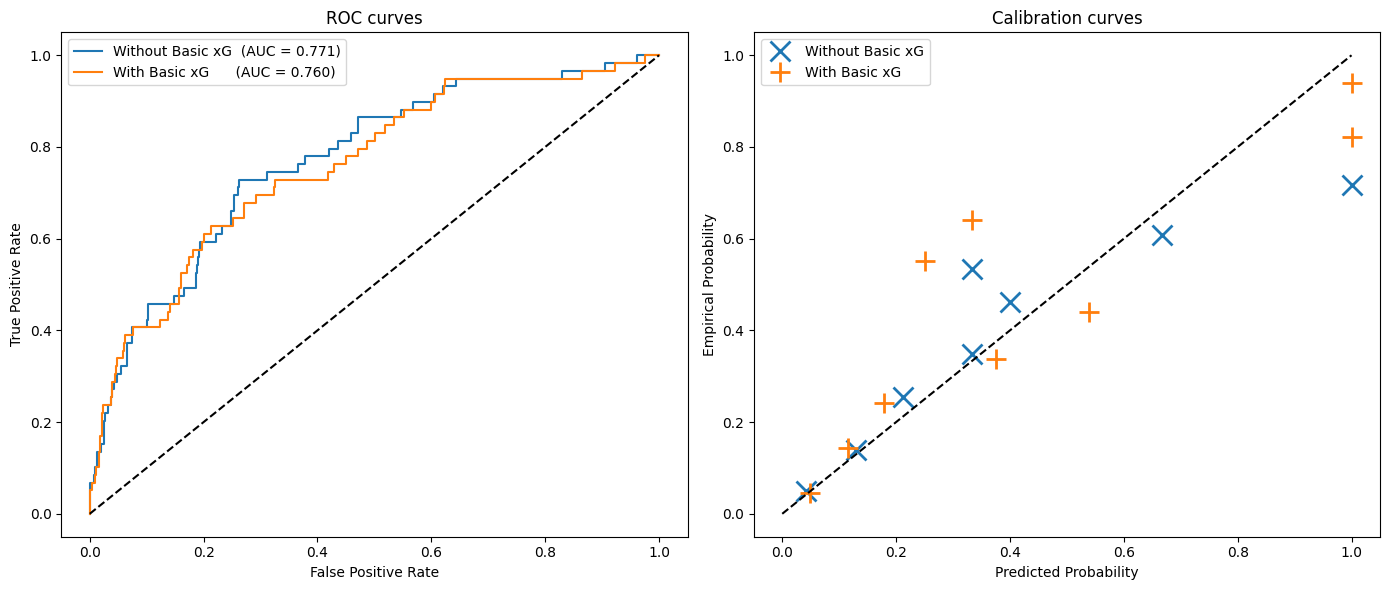

Brier score — Without Basic xG: 0.0810
Brier score — With Basic xG:    0.0806


In [3]:
y_pred_A = model_A.predict(X_cal_A)
y_pred_B = model_B.predict(X_cal)

fpr_A, tpr_A, _ = roc_curve(y_cal, y_pred_A)
fpr_B, tpr_B, _ = roc_curve(y_cal, y_pred_B)
auc_A = roc_auc_score(y_cal, y_pred_A)
auc_B = roc_auc_score(y_cal, y_pred_B)

prob_true_A, prob_pred_A = calibration_curve(y_cal, y_pred_A, n_bins=10)
prob_true_B, prob_pred_B = calibration_curve(y_cal, y_pred_B, n_bins=10)

fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# ROC
axs[0].plot(fpr_A, tpr_A, label=f'Without Basic xG  (AUC = {auc_A:.3f})')
axs[0].plot(fpr_B, tpr_B, label=f'With Basic xG      (AUC = {auc_B:.3f})')
axs[0].plot([0, 1], [0, 1], color='black', ls='--')
axs[0].legend()
axs[0].set_ylabel('True Positive Rate')
axs[0].set_xlabel('False Positive Rate')
axs[0].set_title('ROC curves')

# Calibration
axs[1].plot(prob_true_A, prob_pred_A, 'x', markersize=14, markeredgewidth=2, label='Without Basic xG')
axs[1].plot(prob_true_B, prob_pred_B, '+', markersize=14, markeredgewidth=2, label='With Basic xG')
axs[1].plot([0, 1], [0, 1], color='black', ls='--')
axs[1].legend()
axs[1].set_ylabel('Empirical Probability')
axs[1].set_xlabel('Predicted Probability')
axs[1].set_title('Calibration curves')

plt.tight_layout()
plt.show()

print(f'Brier score — Without Basic xG: {brier_score_loss(y_cal, y_pred_A):.4f}')
print(f'Brier score — With Basic xG:    {brier_score_loss(y_cal, y_pred_B):.4f}')

## SHAP — Model A (without Basic xG)

With Basic xG absent, the model must learn the effect of distance and
angle directly from data. We expect these features to show clear, direct
contributions in the SHAP plot.

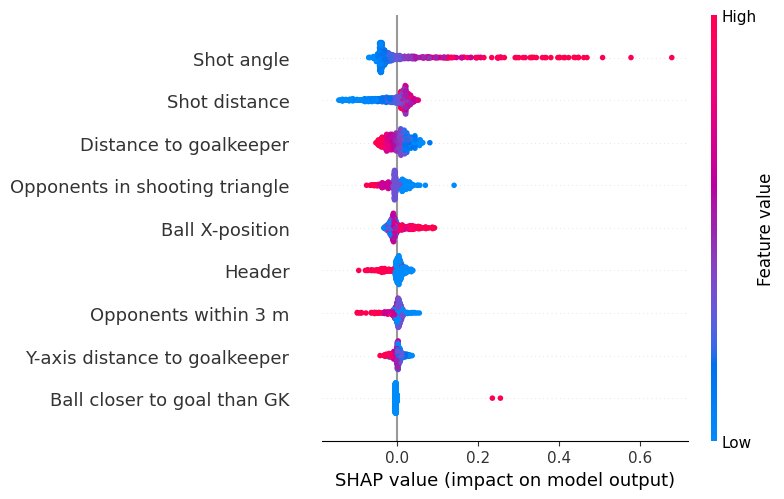

In [4]:
bg_A = X_train_A[:100]
exp_A = shap.DeepExplainer(model_A, bg_A)
sv_A  = exp_A.shap_values(X_cal_A)
sv_A  = sv_A[0] if isinstance(sv_A, list) else sv_A
if sv_A.ndim == 3:
    sv_A = sv_A[:, :, 0]

shap.summary_plot(sv_A, X_cal_A, feature_names=labels_A)

### Interpreting Model A

**SHAP (SHapley Additive exPlanations)** values show how much each feature
pushes the model's prediction up or down relative to the average xG.

- Each row is a feature, ranked by mean absolute SHAP value (most important at top).
- Each dot is one shot. **Horizontal position** = SHAP value (right = increases xG).
- **Colour** indicates the raw feature value: red = high, blue = low.

**The most important feature is *Shot angle*.**  
Its dots spread furthest to the right of all features, meaning it has the largest
positive influence on predicted xG across shots. Red dots (wide angles) cluster
strongly on the right, confirming that shots with a large angle to goal are rated
much more likely to score. The model has learned this directly from the data,
without any pre-computed summary statistic.

**Example - Opponents within 3 m:**  
Blue dots (few opponents nearby) sitting on the right means shots with little
close-range pressure strongly increase predicted xG -- intuitive, since an
unpressured striker is more likely to score.

*Shot distance* similarly shows a clean direct effect: short distances (blue) push
xG up. Both features behave intuitively here because there is no Basic xG feature
competing for the same information.

## SHAP — Model B (with Basic xG)

Adding Basic xG as a feature changes how the model allocates credit.
Because Basic xG already summarises the effect of distance and angle,
those raw features now play a secondary, corrective role.

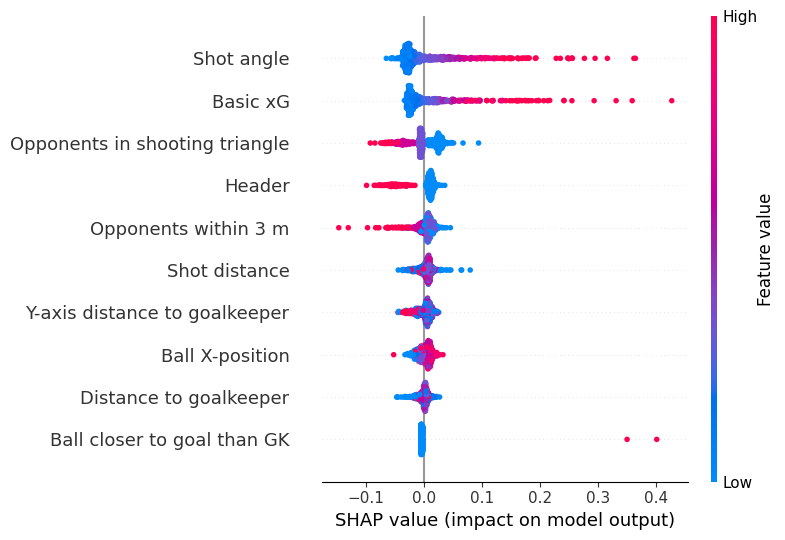

In [5]:
bg_B = X_train[:100]
exp_B = shap.DeepExplainer(model_B, bg_B)
sv_B  = exp_B.shap_values(X_cal)
sv_B  = sv_B[0] if isinstance(sv_B, list) else sv_B
if sv_B.ndim == 3:
    sv_B = sv_B[:, :, 0]

shap.summary_plot(sv_B, X_cal, feature_names=labels_B)

### Interpreting Model B

**Example — Opponents within 3 m** behaves the same as in Model A:
few opponents close by (blue) increases xG.

**Why Shot distance behaves differently here:**  
Basic xG already encodes the effect of distance via a logistic regression.
Once it is included, the raw *Shot distance* feature plays a **dampening
role** — the model uses it to *correct* the Basic xG estimate rather than
to drive predictions independently. This is a common pattern when two
highly correlated features are both present: SHAP values reflect each
feature's *marginal contribution given the other is already there*, which
can appear counterintuitive.

The dominance of *Basic xG* at the top of the plot reflects that a single,
well-specified summary statistic can be more informative than its individual
components — but the tracking features still add value above it.

In [6]:
# --- Quantitative summary of SHAP values for both models ---

# Mean absolute SHAP value = overall feature importance
mean_abs_A = np.abs(sv_A).mean(axis=0)
mean_abs_B = np.abs(sv_B).mean(axis=0)

# Pearson correlation between feature value and its SHAP value
# Positive  -> higher feature value increases xG
# Negative  -> higher feature value decreases xG
def shap_direction(sv, X):
    return np.array([np.corrcoef(X[:, j], sv[:, j])[0, 1] for j in range(sv.shape[1])])

dir_A = shap_direction(sv_A, X_cal_A)
dir_B = shap_direction(sv_B, X_cal)

def arrow(r):
    return '↑ increases xG' if r > 0 else '↓ decreases xG'

df_A = pd.DataFrame({
    'Feature':     labels_A,
    'Mean |SHAP|': mean_abs_A.round(4),
    'Direction':   [arrow(r) for r in dir_A],
    'Corr':        dir_A.round(3),
}).sort_values('Mean |SHAP|', ascending=False).reset_index(drop=True)
df_A.index += 1

df_B = pd.DataFrame({
    'Feature':     labels_B,
    'Mean |SHAP|': mean_abs_B.round(4),
    'Direction':   [arrow(r) for r in dir_B],
    'Corr':        dir_B.round(3),
}).sort_values('Mean |SHAP|', ascending=False).reset_index(drop=True)
df_B.index += 1

print('=== Model A: Tracking features only (ranked by importance) ===')
print(df_A[['Feature', 'Mean |SHAP|', 'Direction', 'Corr']].to_string())
print()
print('=== Model B: Tracking features + Basic xG (ranked by importance) ===')
print(df_B[['Feature', 'Mean |SHAP|', 'Direction', 'Corr']].to_string())

# Sanity checks: verify directions agree with football intuition
print()
print('--- Sanity checks ---')
for label, key, expected_sign in [
    ('Shot distance',                  'distance',      -1),
    ('Shot angle',                     'angle',         +1),
    ('Header',                         'header',        -1),
    ('Opponents in shooting triangle', 'triangle',      -1),
    ('Opponents within 3 m',           'close_players', -1),
]:
    if key in keys_A:
        j = keys_A.index(key)
        corr = dir_A[j]
        ok = '✓' if (corr * expected_sign) > 0 else '✗ UNEXPECTED'
        print(f'  Model A | {label:42s} corr={corr:+.3f}  {ok}')
    if key in keys_B:
        j = keys_B.index(key)
        corr = dir_B[j]
        ok = '✓' if (corr * expected_sign) > 0 else '✗ UNEXPECTED'
        print(f'  Model B | {label:42s} corr={corr:+.3f}  {ok}')


=== Model A: Tracking features only (ranked by importance) ===
                          Feature  Mean |SHAP|       Direction   Corr
1                      Shot angle       0.0618  ↑ increases xG  0.943
2                   Shot distance       0.0301  ↑ increases xG  0.682
3          Distance to goalkeeper       0.0216  ↓ decreases xG -0.918
4  Opponents in shooting triangle       0.0173  ↓ decreases xG -0.908
5                 Ball X-position       0.0164  ↑ increases xG  0.657
6                          Header       0.0127  ↓ decreases xG -0.762
7            Opponents within 3 m       0.0100  ↓ decreases xG -0.613
8   Y-axis distance to goalkeeper       0.0081  ↓ decreases xG -0.771
9     Ball closer to goal than GK       0.0039  ↑ increases xG  0.995

=== Model B: Tracking features + Basic xG (ranked by importance) ===
                           Feature  Mean |SHAP|       Direction   Corr
1                       Shot angle       0.0410  ↑ increases xG  0.968
2                        

## What the SHAP Values Tell Us About Scoring Goals

The tables and beeswarm plots above reveal a consistent story about what makes a shot more or less likely to result in a goal.

---

### Features that *increase* xG (higher value → more likely to score)

| Feature | Intuition |
|---|---|
| **Shot angle** | A wider angle exposes more of the goal to the shooter. The clearest positive driver in Model A — learned directly from outcomes with no pre-baked summary statistic. |
| **Ball closer to goal than GK** (`is_closer = 1`) | If the ball is nearer the goal line than the keeper, they must retreat to intercept any shot, giving the attacker a decisive spatial advantage. |
| **Y-axis distance to goalkeeper** | A keeper displaced laterally from the ball's path leaves more of the goal unguarded. High lateral GK distance consistently pushes xG up. |

---

### Features that *decrease* xG (higher value → less likely to score)

| Feature | Intuition |
|---|---|
| **Shot distance** | The strongest negative driver. Greater distance gives the keeper more reaction time, compresses the apparent goal size, and reduces shooting accuracy and power. |
| **Opponents in the shooting triangle** | Each defender between ball and goalposts blocks lanes, can deflect the shot, and forces the shooter to aim for tighter gaps. |
| **Opponents within 3 m** | Close pressure forces rushed technique, reduces the time to pick a target, and increases the chance of a blocked or miscued attempt. |
| **Header** | Headers are harder to direct and generate less power than struck shots. Both models assign a clear negative SHAP contribution to heading attempts, consistent with empirical conversion rates being roughly half those of foot shots. |

---

### Model B: what Basic xG adds

Once Basic xG is in the feature set it rises to the **top of the importance ranking**, absorbing the geometric signal already carried by raw distance and angle. Those two features then shift to a **corrective role** — helping the network adjust the Basic xG estimate in cases where the linear logistic approximation is too high or too low (e.g. a close shot with the keeper perfectly positioned, or a medium-range shot with a completely open goal). This redistribution is expected: SHAP values reflect *marginal* contribution given all other features, so adding a highly informative summary statistic inevitably reduces the marginal value of its components.

The tracking-only features (GK positioning, defensive pressure, header) retain similar importance across both models, confirming they carry genuine information beyond the shot geometry alone.

---

> **Summary: the most decisive factors for scoring are spatial geometry (distance and angle) and goalkeeper vulnerability. Defensive pressure compounds the difficulty. Both neural network models agree on these directions — a useful consistency check that the SHAP values are physically meaningful.**


## Backward Stepwise Logistic Regression

We start with all ten features and remove one at a time, always dropping the variable with the highest (least significant) p-value until every remaining variable is significant at the 5 % level. This gives us the most parsimonious logistic model whose AIC we can compare with the neural network results above.

*(Note: `xg_basic` is a derived feature so results with and without it are both shown.)*

In [7]:
import statsmodels.formula.api as smf
import statsmodels.api as sm_api

# Use the full dataset (un-scaled) — statsmodels handles scale internally
df = model_vars.copy()

SEP = '=' * 60

def backward_stepwise(df, response, candidates, alpha=0.05, label=''):
    """Backward elimination by highest p-value. Returns final model."""
    remaining = list(candidates)
    step = 0
    print('\n' + SEP)
    print('Backward stepwise logistic regression  ' + label)
    print('Starting variables (' + str(len(remaining)) + '): ' + str(remaining))
    print(SEP)

    while True:
        formula = response + ' ~ ' + ' + '.join(remaining)
        model = smf.glm(formula=formula, data=df,
                        family=sm_api.families.Binomial()).fit()

        # p-values for everything except the Intercept
        pvals = model.pvalues.drop('Intercept')
        worst_var  = pvals.idxmax()
        worst_pval = pvals.max()

        step += 1
        print(f'\nStep {step}  |  AIC={model.aic:.1f}  |  '
              f'worst: {worst_var} (p={worst_pval:.4f})')

        if worst_pval > alpha:
            print(f'  -> Removing "{worst_var}" (p={worst_pval:.4f} > {alpha})')
            remaining.remove(worst_var)
        else:
            print(f'  -> All remaining variables significant at alpha={alpha}. Stopping.')
            break

        if len(remaining) == 0:
            print('No variables left.')
            break

    print(f'\nFinal model variables ({len(remaining)}): {remaining}')
    print(f'Final AIC: {model.aic:.2f}')
    print('\nCoefficients and p-values:')
    summary = model.pvalues.reset_index()
    summary.columns = ['Variable', 'p-value']
    coef = model.params.reset_index()
    coef.columns = ['Variable', 'Coefficient']
    result = coef.merge(summary, on='Variable')
    result['Significant'] = result['p-value'].apply(lambda p: 'Yes' if p < alpha else 'No')
    print(result.to_string(index=False))
    return model, remaining

# --- Run 1: all 9 tracking features (no xg_basic) ---
tracking_vars = ['x0', 'is_closer', 'angle', 'distance',
                 'gk_distance', 'gk_distance_y', 'triangle', 'close_players', 'header']
model_step_A, kept_A = backward_stepwise(df, 'goal', tracking_vars,
                                          label='(tracking features only)')

# --- Run 2: all 10 features including xg_basic ---
all_vars = tracking_vars + ['xg_basic']
model_step_B, kept_B = backward_stepwise(df, 'goal', all_vars,
                                          label='(tracking features + Basic xG)')

# --- AIC comparison table ---
print('\n' + SEP)
print('AIC comparison')
print(SEP)
for lbl, kept, model in [
    ('Tracking only  - all 9 vars', tracking_vars,
     smf.glm('goal ~ ' + ' + '.join(tracking_vars), data=df,
             family=sm_api.families.Binomial()).fit()),
    (f'Tracking only  - kept {len(kept_A)} vars', kept_A, model_step_A),
    ('Tracking + xgbasic - all 10 vars', all_vars,
     smf.glm('goal ~ ' + ' + '.join(all_vars), data=df,
             family=sm_api.families.Binomial()).fit()),
    (f'Tracking + xgbasic - kept {len(kept_B)} vars', kept_B, model_step_B),
]:
    print(f'  {lbl:45s}  AIC={model.aic:.1f}')



Backward stepwise logistic regression  (tracking features only)
Starting variables (9): ['x0', 'is_closer', 'angle', 'distance', 'gk_distance', 'gk_distance_y', 'triangle', 'close_players', 'header']

Step 1  |  AIC=1631.3  |  worst: gk_distance_y (p=0.3454)
  -> Removing "gk_distance_y" (p=0.3454 > 0.05)

Step 2  |  AIC=1630.3  |  worst: distance (p=0.3712)
  -> Removing "distance" (p=0.3712 > 0.05)

Step 3  |  AIC=1629.1  |  worst: x0 (p=0.0501)
  -> Removing "x0" (p=0.0501 > 0.05)

Step 4  |  AIC=1630.9  |  worst: close_players (p=0.0257)
  -> All remaining variables significant at alpha=0.05. Stopping.

Final model variables (6): ['is_closer', 'angle', 'gk_distance', 'triangle', 'close_players', 'header']
Final AIC: 1630.89

Coefficients and p-values:
     Variable  Coefficient      p-value Significant
    Intercept    -1.590362 1.423930e-08         Yes
    is_closer     1.584753 5.961531e-03         Yes
        angle     0.033398 2.182592e-13         Yes
  gk_distance    -0.06038

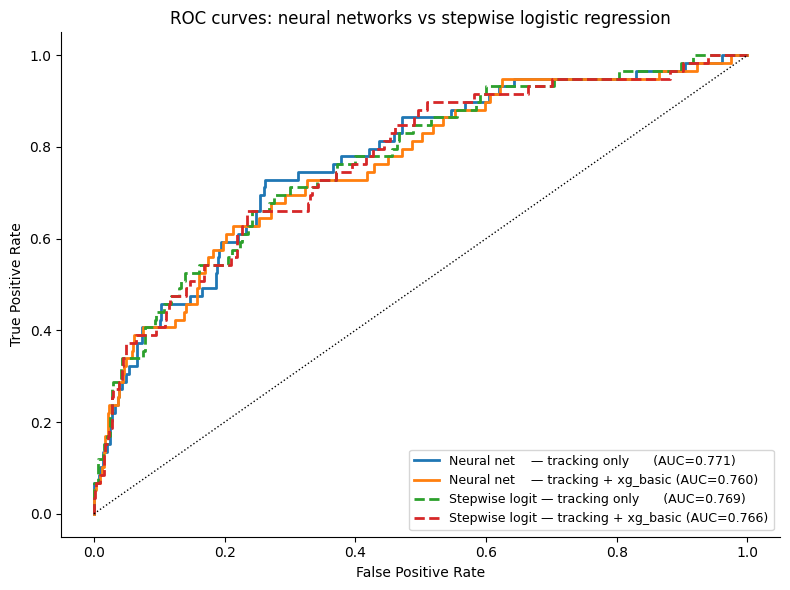

AUC summary
  Neural net    — tracking only:        0.7714
  Neural net    — tracking + xg_basic:  0.7597
  Stepwise logit — tracking only:        0.7691
  Stepwise logit — tracking + xg_basic:  0.7662


In [8]:
# --- ROC comparison: stepwise logistic regression vs neural networks ---

# Build calibration DataFrame from unscaled data for statsmodels predict
cal_df = pd.DataFrame(X_cal_all, columns=keys_B)

# Predict on calibration set using each stepwise model
y_pred_step_A = model_step_A.predict(cal_df[kept_A])
y_pred_step_B = model_step_B.predict(cal_df[kept_B])

# ROC curves for stepwise models
fpr_sA, tpr_sA, _ = roc_curve(y_cal, y_pred_step_A)
fpr_sB, tpr_sB, _ = roc_curve(y_cal, y_pred_step_B)
auc_sA = roc_auc_score(y_cal, y_pred_step_A)
auc_sB = roc_auc_score(y_cal, y_pred_step_B)

fig, ax = plt.subplots(figsize=(8, 6))

# Neural network curves (computed earlier)
ax.plot(fpr_A,  tpr_A,  lw=2,       label=f'Neural net    \u2014 tracking only      (AUC={auc_A:.3f})')
ax.plot(fpr_B,  tpr_B,  lw=2,       label=f'Neural net    \u2014 tracking + xg_basic (AUC={auc_B:.3f})')

# Stepwise logistic regression curves (dashed)
ax.plot(fpr_sA, tpr_sA, lw=2, ls='--', label=f'Stepwise logit \u2014 tracking only      (AUC={auc_sA:.3f})')
ax.plot(fpr_sB, tpr_sB, lw=2, ls='--', label=f'Stepwise logit \u2014 tracking + xg_basic (AUC={auc_sB:.3f})')

ax.plot([0, 1], [0, 1], color='black', ls=':', lw=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC curves: neural networks vs stepwise logistic regression')
ax.legend(loc='lower right', fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print('AUC summary')
print(f'  Neural net    \u2014 tracking only:        {auc_A:.4f}')
print(f'  Neural net    \u2014 tracking + xg_basic:  {auc_B:.4f}')
print(f'  Stepwise logit \u2014 tracking only:        {auc_sA:.4f}')
print(f'  Stepwise logit \u2014 tracking + xg_basic:  {auc_sB:.4f}')


In [14]:

# --- Contribution plot for stepwise logistic regression models ---
# Each shot's per-feature contribution to log-odds: β_j * (x_ij − μ_j)
# Colour = z-scored feature value (red = high, blue = low)
# Hover shows angle (degrees) and distance for each shot

import plotly.graph_objects as go

N_SAMPLE = 200
CLAMP    = 2.0   # colour scale spans ±2 std devs for clear contrast
rng        = np.random.default_rng(42)
sample_idx = rng.choice(len(model_vars), size=N_SAMPLE, replace=False)
df_sample  = model_vars.iloc[sample_idx].reset_index(drop=True)
angle_deg  = df_sample['angle'].values   # already in degrees
dist_m     = df_sample['distance'].values

def contrib_plot(model, kept, title):
    """Beeswarm-style contribution plot using β_j*(x_ij − μ_j)."""
    b   = model.params          # statsmodels named Series: var -> coefficient
    n   = len(df_sample)
    nf  = len(kept)

    contribs  = np.zeros((n, nf))
    feat_norm = np.zeros((n, nf))

    for j, v in enumerate(kept):
        mu_j  = model_vars[v].mean()
        std_j = model_vars[v].std()
        contribs[:, j]  = b[v] * (df_sample[v].values - mu_j)
        feat_norm[:, j] = (df_sample[v].values - mu_j) / (std_j + 1e-12)

    order = np.argsort(np.abs(contribs).mean(axis=0))   # least → most important

    fig = go.Figure()
    for row_idx, j in enumerate(order):
        v       = kept[j]
        lbl     = feature_info[v][0]
        y_jit   = rng.uniform(-0.35, 0.35, size=n)
        show_cb = (row_idx == nf - 1)

        hover = [
            f"<b>{lbl}</b><br>"
            f"Angle: {angle_deg[i]:.1f}\u00b0<br>"
            f"Distance: {dist_m[i]:.1f} m<br>"
            f"Contribution: {contribs[i, j]:.4f}"
            for i in range(n)
        ]

        mo = dict(
            color=np.clip(feat_norm[:, j], -CLAMP, CLAMP),
            colorscale='RdBu', reversescale=True,
            cmin=-CLAMP, cmax=CLAMP,
            opacity=0.65, size=5,
            showscale=show_cb,
        )
        if show_cb:
            mo['colorbar'] = dict(
                title='Feature value<br>(std devs)',
                tickvals=[-2, -1, 0, 1, 2],
                ticktext=['\u22122\u03c3', '\u22121\u03c3', 'Mean', '+1\u03c3', '+2\u03c3'],
            )

        fig.add_trace(go.Scatter(
            x=contribs[:, j], y=row_idx + y_jit, mode='markers',
            marker=mo, text=hover,
            hovertemplate='%{text}<extra></extra>', showlegend=False,
        ))

    fig.update_layout(
        width=750, height=max(300, 45 * nf + 100),
        title=title,
        xaxis=dict(
            title='\u03b2<sub>j</sub>(x<sub>ij</sub> \u2212 \u03bc<sub>j</sub>)  [log-odds contribution]',
            zeroline=True, zerolinecolor='black', zerolinewidth=1, showgrid=False,
        ),
        yaxis=dict(
            tickmode='array',
            tickvals=list(range(nf)),
            ticktext=[feature_info[kept[j]][0] for j in order],
            showgrid=False,
        ),
        plot_bgcolor='white',
        margin=dict(l=200, r=120, t=60, b=60),
    )
    fig.show()

contrib_plot(model_step_A, kept_A,
             'Feature contributions \u2014 Stepwise logit (tracking only)')
contrib_plot(model_step_B, kept_B,
             'Feature contributions \u2014 Stepwise logit (tracking + xg_basic)')


In [21]:

# How much does each variable need to change to produce a +20% increase in odds?
# From logistic regression:  β * Δx = ln(1.20)  →  Δx = ln(1.20) / β

from IPython.display import display

TARGET_ODDS_PCT = 20                                    # desired % increase in odds
TARGET_LOG_ODDS = np.log(1 + TARGET_ODDS_PCT / 100)    # = ln(1.20) ≈ 0.182

# Units for display
units = {
    'angle':         'degrees',
    'distance':      'm',
    'x0':            'm',
    'gk_distance':   'm',
    'gk_distance_y': 'm',
    'triangle':      'opponents',
    'close_players': 'opponents',
    'is_closer':     'frequency',
    'header':        'frequency',
    'xg_basic':      'xG units',
}

model_specs = [
    ('Stepwise logit — tracking only',       model_step_A, kept_A),
    ('Stepwise logit — tracking + Basic xG', model_step_B, kept_B),
]

for model_name, step_model, kept in model_specs:
    coefs = step_model.params
    print(f'{model_name}  '
          f'(target +{TARGET_ODDS_PCT}% odds = log-odds change {TARGET_LOG_ODDS:.4f}, '
          f'odds ratio {np.exp(TARGET_LOG_ODDS):.4f})')
    results = []
    for var in kept:
        if var not in coefs.index:
            continue
        beta = coefs[var]
        if abs(beta) < 1e-10:
            continue
        req = TARGET_LOG_ODDS / beta
        unit = units.get(var, '')
        direction = 'increase' if req > 0 else 'decrease'
        # Sort key: mean absolute contribution = |β| * mean|x - μ|
        # (same metric as the contribution plot)
        mean_abs_contrib = abs(beta) * (model_vars[var] - model_vars[var].mean()).abs().mean()
        results.append({
            'Feature':         feature_info[var][0],
            'Direction':       direction,
            'Required change': f'{abs(req):.2f}',
            'Units':           unit,
            '_importance':     mean_abs_contrib,
        })
    df_req = (pd.DataFrame(results)
                .sort_values('_importance', ascending=False)
                .drop(columns='_importance')
                .reset_index(drop=True))
    display(df_req.style.hide(axis='index'))
    print()


Stepwise logit — tracking only  (target +20% odds = log-odds change 0.1823, odds ratio 1.2000)


Feature,Direction,Required change,Units
Shot angle,increase,5.46,degrees
Distance to goalkeeper,decrease,3.02,m
Opponents in shooting triangle,decrease,0.50,opponents
Header,decrease,0.27,frequency
Opponents within 3 m,decrease,1.07,opponents
Ball closer to goal than GK,increase,0.12,frequency



Stepwise logit — tracking + Basic xG  (target +20% odds = log-odds change 0.1823, odds ratio 1.2000)


Feature,Direction,Required change,Units
Distance to goalkeeper,decrease,1.45,m
Ball X-position,decrease,2.59,m
Basic xG,increase,0.03,xG units
Opponents in shooting triangle,decrease,0.52,opponents
Header,decrease,0.33,frequency
Opponents within 3 m,decrease,1.07,opponents
Ball closer to goal than GK,increase,0.12,frequency
